In [14]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from astropy import units as u 
from astropy.cosmology import FlatLambdaCDM

In [2]:
import gzip
import shutil

with gzip.open("catalog.dat.gz", "rb") as f_in:
    with open("catalog.dat", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

In [3]:
shen2011 = Table.read(
    "catalog.dat",
    format="ascii.cds",
    readme="ReadMe.txt"
)

print("Number of Shen 2011 QSOs:", len(shen2011))
#print(shen2011.colnames)

Number of Shen 2011 QSOs: 105783


In [4]:
#open the catalog 2022

filename = "dr16q_prop_Oct23_2022.fits.gz"

catalog = Table.read(filename, hdu=1)

print("Number of QSOs:", len(catalog))
print(catalog.colnames)

Number of QSOs: 750414
['SDSS_NAME', 'PLATE', 'MJD', 'FIBERID', 'RA', 'DEC', 'OBJID', 'IF_BOSS_SDSS', 'Z_DR16Q', 'SOURCE_Z_DR16Q', 'Z_FIT', 'Z_SYS', 'Z_SYS_ERR', 'EBV', 'SN_MEDIAN_ALL', 'CONTI_FIT', 'CONTI_FIT_ERR', 'CONTI_STAT', 'FEII_UV', 'FEII_UV_ERR', 'FEII_UV_EW', 'FEII_UV_EW_ERR', 'FEII_OPT', 'FEII_OPT_ERR', 'FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'HALPHA', 'HALPHA_BR', 'NII6585', 'SII6718', 'HBETA', 'HBETA_BR', 'HEII4687', 'HEII4687_BR', 'OIII5007', 'OIII5007C', 'CAII3934', 'OII3728', 'NEV3426', 'MGII', 'MGII_BR', 'CIII_ALL', 'CIII_BR', 'SIIII1892', 'ALIII1857', 'NIII1750', 'CIV', 'HEII1640', 'HEII1640_BR', 'SIIV_OIV', 'OI1304', 'LYA', 'NV1240', 'HALPHA_ERR', 'HALPHA_BR_ERR', 'NII6585_ERR', 'SII6718_ERR', 'HBETA_ERR', 'HBETA_BR_ERR', 'HEII4687_ERR', 'HEII4687_BR_ERR', 'OIII5007_ERR', 'OIII5007C_ERR', 'CAII3934_ERR', 'OII3728_ERR', 'NEV3426_ERR', '

In [28]:
#extract the features that are needed

"""
Z_SYS = systemic redshift
LOGL1350 = continuum luminosity at rest-frame 1350 angstroms
HALPHA = Halpha emission-line measurement
HALPHA_ERR = Halpha line error
HBETA = Hbeta emission-line measurement
HBETA_ERR = Hbeta line error
MGII = Mg II emission-line measurement
MGII_ERR = MgII line error
CIV = CIV emission-line measurement
CIV_ERR = CIV line error

"""

col = ["Z_SYS", "LOGL1350", "HALPHA", "HALPHA_ERR", "HBETA", "HBETA_ERR", "MGII", "MGII_ERR", "CIV", "CIV_ERR"]

#the lines have 6 numbers per quasar we need to find the line luminosity
#the recommended quality cut for Wu and Shen is 38 < log(L) < 48
print(catalog["HALPHA"].shape)

for line in ["HALPHA", "HBETA", "MGII", "CIV"]:
    print(line)
    for i in range(6):
        print(i, catalog[line][0, i])

(750414, 6)
HALPHA
0 0.0
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
HBETA
0 4862.538395321536
1 4854.166496184568
2 1555.6063387287843
3 43.72998403479187
4 5690.050362561654
5 158.55024238933106
MGII
0 2802.3081094977
1 2799.61800058238
2 1111.403968712517
3 43.58395627393963
4 4819.454174002242
5 28.006254362596195
CIV
0 0.0
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0


In [6]:
#assign variables
z = catalog["Z_SYS"]
logL1350 = catalog["LOGL1350"]
logL_Halpha = catalog["HALPHA"][:, 3]
logL_Hbeta  = catalog["HBETA"][:, 3]
logL_MgII   = catalog["MGII"][:, 3]
logL_CIV    = catalog["CIV"][:, 3]

In [7]:
#quality cuts
#keep the quasar only if all conditions are true 

good_Halpha = (z > 0) & (logL_Halpha > 38) & (logL_Halpha < 48)
good_Hbeta = (z > 0) & (logL_Hbeta > 38) & (logL_Hbeta < 48)
good_MgII = (z > 0) & (logL1350>0) & (logL_MgII > 38) & (logL_MgII < 48)
good_CIV = (z > 0) & (logL1350>0) & (logL_CIV > 38) & (logL_CIV < 48)

#check how many objects survive
print("Good Halpha lines:", np.sum(good_Halpha))
print("Good Hbeta lines:", np.sum(good_Hbeta))
print("Good MgII lines:", np.sum(good_MgII))
print("Good CIV lines:", np.sum(good_CIV))

Good Halpha lines: 24418
Good Hbeta lines: 165211
Good MgII lines: 299704
Good CIV lines: 376396


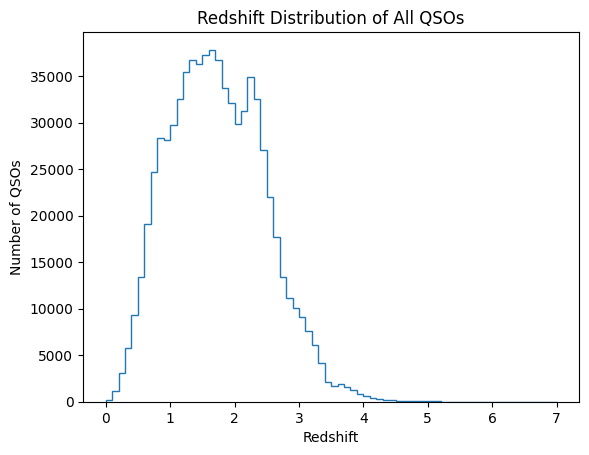

In [36]:
#redshift distribution
z_bins = z_bins = np.arange(0, 7.1, 0.1)
good_z = np.isfinite(z) & (z > 0)

plt.hist(z[good_z], bins=z_bins, histtype="step")

plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.title("Redshift Distribution of All QSOs")
plt.show()

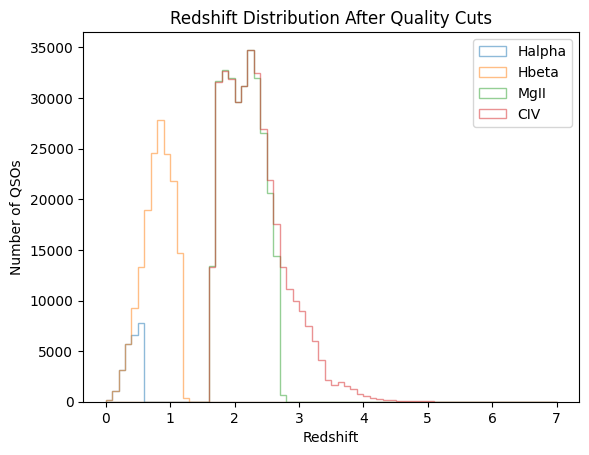

In [37]:
#redshift distribution
plt.hist(z[good_Halpha], bins = z_bins, alpha = 0.5, label = "Halpha", histtype = "step")
plt.hist(z[good_Hbeta], bins = z_bins, alpha = 0.5, label = "Hbeta", histtype = "step")
plt.hist(z[good_MgII], bins = z_bins, alpha = 0.5, label = "MgII", histtype = "step")
plt.hist(z[good_CIV], bins = z_bins, alpha = 0.5, label = "CIV", histtype = "step")

plt.xlabel("Redshift")
plt.ylabel("Number of QSOs")
plt.title("Redshift Distribution After Quality Cuts")
plt.legend()
plt.show()

#bins are different

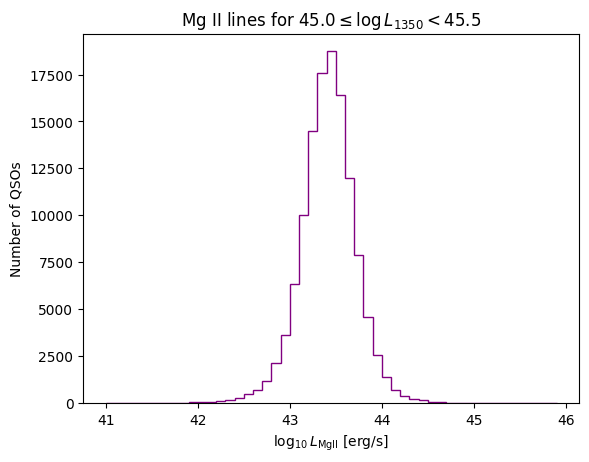

In [38]:
L_low = 45.0
L_high = 45.5

selected = (good_MgII & (logL1350 >= 45.0) & (logL1350 < 45.5))

MgII_values = logL_MgII[selected]

plt.hist(MgII_values,bins=np.arange(41, 46, 0.1),histtype="step",color="purple")

plt.xlabel(r"$\log_{10} L_{\mathrm{MgII}}$ [erg/s]")
plt.ylabel("Number of QSOs")
plt.title(r"Mg II lines for $45.0 \leq \log L_{1350} < 45.5$")
plt.show()

Log line-luminosity threshold: 42.88835572594223
Fraction above threshold: 0.9582696249064706


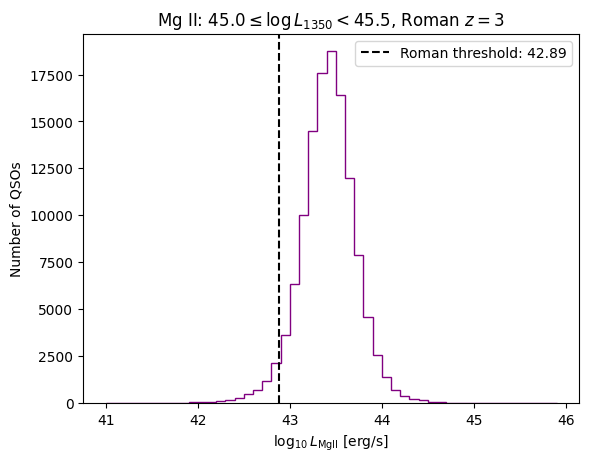

In [32]:
# Assumed Roman flux limit and test redshift
f_lim = 1e-16 * u.erg / (u.s * u.cm**2)
z_roman = 3.0
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Convert flux limit to line-luminosity limit
d_L = cosmo.luminosity_distance(z_roman).to(u.cm)
L_lim = 4 * np.pi * d_L**2 * f_lim
logL_lim = np.log10(L_lim.to_value(u.erg / u.s))

# Fraction of this selected sample above the threshold
detected = MgII_values > logL_lim
P_Roman = np.sum(detected) / len(MgII_values)

print("Log line-luminosity threshold:", logL_lim)
print("Fraction above threshold:", P_Roman)

# Plot the histogram and threshold
plt.hist(MgII_values,bins=np.arange(41, 46, 0.1),histtype="step",color="purple")

plt.axvline(logL_lim,color="black",linestyle="--",label=f"Roman threshold: {logL_lim:.2f}")

plt.xlabel(r"$\log_{10} L_{\mathrm{MgII}}$ [erg/s]")
plt.ylabel("Number of QSOs")
plt.title(r"Mg II: $45.0 \leq \log L_{1350} < 45.5$, Roman $z=3$")
plt.legend()
plt.show()

In [33]:
# All quasars in the chosen UV-brightness bin
in_bin_all = ((z > 0)& (logL1350 >= 45.0)& (logL1350 < 45.5))

# Same UV bin, also passing the Mg II cuts
in_bin_MgII = in_bin_all & good_MgII

N_all = np.sum(in_bin_all)
N_valid = np.sum(in_bin_MgII)

print("All QSOs in UV bin:", N_all)
print("QSOs passing Mg II cuts:", N_valid)
print("QSOs not passing Mg II cuts:", N_all - N_valid)

All QSOs in UV bin: 140181
QSOs passing Mg II cuts: 122956
QSOs not passing Mg II cuts: 17225


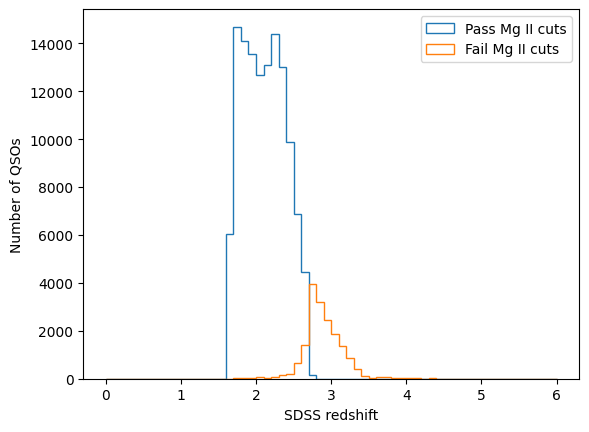

In [34]:
z_bins = np.arange(0, 6.1, 0.1) #above 3 outside of BOSS range

missing_MgII = in_bin_all & ~good_MgII

plt.hist(z[in_bin_MgII], bins=z_bins,
         histtype="step", label="Pass Mg II cuts")

plt.hist(z[missing_MgII], bins=z_bins,
         histtype="step", label="Fail Mg II cuts")

plt.xlabel("SDSS redshift")
plt.ylabel("Number of QSOs")
plt.legend()
plt.show()

In [ ]:
UV = []
P = []
for L_low in [44, 44.5, 45, 45.5, 46, 46.5]:

    L_high = L_low + 0.5

    selected = (good_MgII & (logL1350 >= L_low) & (logL1350 < L_high))

    lines = logL_MgII[selected]

    if len(lines) > 0:
        probability = np.sum(lines > logL_lim) / len(lines)
        print(L_low, L_high, probability)

        UV.append((L_low + L_high) / 2) #center of the interval
        P.append(probability)

        print(L_low, L_high, probability)

plt.plot(UV, P, "o-", color="purple")
plt.xlabel(r"$\log_{10} L_{1350}$ [erg/s]")
plt.ylabel("Fraction above Roman threshold")
plt.title("Preliminary Mg II fractions — Roman z = 3")
plt.ylim(0, 1.05)
plt.show()

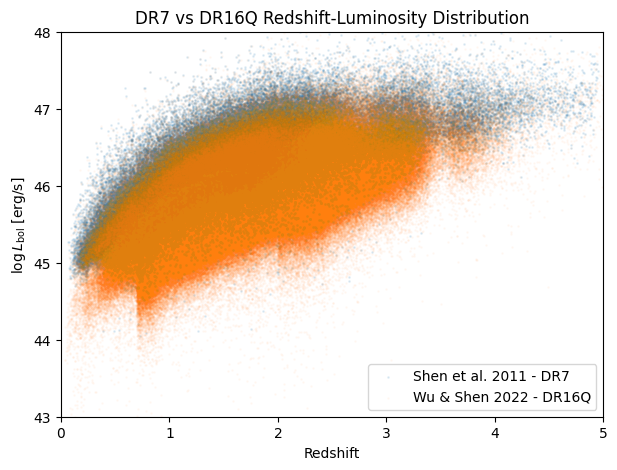

In [35]:
# Compare Shen et al. 2011 DR7 with Wu & Shen 2022 DR16Q

# Old catalog: Shen et al. 2011
z_old = shen2011["z"]
Lbol_old = shen2011["logLbol"]

good_old = ((z_old > 0) & (Lbol_old > 0))

# New catalog: Wu & Shen 2022
z_new = catalog["Z_SYS"]
Lbol_new = catalog["LOGLBOL"]

good_new = ((z_new > 0) & (Lbol_new > 0))

plt.figure(figsize=(7, 5))

plt.scatter(z_old[good_old],Lbol_old[good_old],s=1,alpha=0.1,label="Shen et al. 2011 - DR7")

plt.scatter(z_new[good_new],Lbol_new[good_new],s=1,alpha=0.03,label="Wu & Shen 2022 - DR16Q")

plt.xlabel("Redshift")
plt.ylabel(r"$\log L_{\rm bol}$ [erg/s]")

plt.xlim(0, 5)
plt.ylim(43, 48)

plt.title("DR7 vs DR16Q Redshift-Luminosity Distribution")

plt.legend()

plt.show()